In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


In [ ]:
import importlib
import coupling_utils as cl
import element

importlib.reload(cl)
importlib.reload(element)

from element import get_matrix_element


old code if needed

In [3]:
import sys
import os

MG_DIR = "/home/alex/MG5_aMC_v3_7_0/tdecay/SubProcesses/P1_t_bepve"

print("Exists:", os.path.exists(MG_DIR))
print("Files:", os.listdir(MG_DIR)[:10])

sys.path.append(MG_DIR)

import matrix2py
print("matrix2py loaded from:", matrix2py.__file__)

Exists: True
Files: ['check', 'matrix.o', 'libmeP1_t_bepve.so', 'param.log', 'matrix.f', 'matrix.ps', 'f2py_matrix_wrapper.f', 'test.py', 'matrix2py.cpython-312-x86_64-linux-gnu.so', 'libdhelas.so']
matrix2py loaded from: /home/alex/MG5_aMC_v3_7_0/tdecay/SubProcesses/P1_t_bepve/matrix2py.cpython-312-x86_64-linux-gnu.so


In [4]:
PARAM_CARD = "/home/alex/MG5_aMC_v3_7_0/tdecay/Cards/param_card.dat"

matrix2py.py_initialisemodel(PARAM_CARD)

print("Model initialised")

Model initialised


Testing one matrix element evaluation

In [13]:
p = [[   173,  0.0000000E+00,  0.0000000E+00,  0.0000000E+03],
     [   0.5000000E+03,  0.0000000E+00,  0.0000000E+00, -0.5000000E+03],
     [   0.5000000E+03,  0.1109243E+03,  0.4448308E+03, -0.1995529E+03],
     [   0.5000000E+03, -0.1109243E+03, -0.4448308E+03,  0.1995529E+03]]

print(get_matrix_element(p))


E1 = 20
E2 = 50
cos1 = 0.3
phi1 = 2.1
phi2 = 0.4



#sin1 = sqrt(1-cos1**2)

#p1 = [ E1, E1*sin(phi1)*sin1 , E1* cos(phi1)*sin1   , E1*cos1]

#p2 = E2 * [1, ] 

#p3 = [mt, 0,0,0] - p1 -p2 

0.011162172659316188


Let's do this

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
dtype = torch.float32

Using device: cuda


tensor(1.1129)


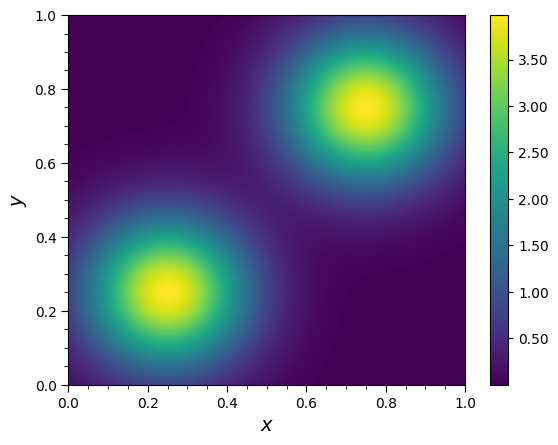

In [ ]:
camel = cl.camel
cl.plot_f_2d(camel, 1000)


In [18]:
#define flow parameters

A_dims = [torch.tensor([0]),
          torch.tensor([1])]

B_dims = [torch.tensor([1]),
          torch.tensor([0])]

In [25]:
#train flow
final_loss, losses, flow = cl.train_loop_complete(
    f=camel,
    D=2,
    layer_type=cl.pwq_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=32,
    hidden_size=16,
    N=10_000,
    epochs=5000,
    lr=1.2e-4,
    device=device,
    ticker=True
)


Epoch: 0 | Loss: 1.13623440e+00
Mean value:  0.9312598705291748
Epoch: 20 | Loss: 1.10464668e+00
Mean value:  0.9191969037055969
Epoch: 40 | Loss: 1.10726118e+00
Mean value:  0.9237057566642761
Epoch: 60 | Loss: 1.06899929e+00
Mean value:  0.9086084961891174
Epoch: 80 | Loss: 1.07660341e+00
Mean value:  0.9188662171363831
Epoch: 100 | Loss: 1.08073997e+00
Mean value:  0.9299354553222656
Epoch: 120 | Loss: 1.04872334e+00
Mean value:  0.9245458245277405
Epoch: 140 | Loss: 1.03879452e+00
Mean value:  0.9224897623062134
Epoch: 160 | Loss: 1.01576328e+00
Mean value:  0.9325024485588074
Epoch: 180 | Loss: 9.97594535e-01
Mean value:  0.916318953037262
Epoch: 200 | Loss: 9.92155910e-01
Mean value:  0.9262087941169739
Epoch: 220 | Loss: 9.53689456e-01
Mean value:  0.9152184724807739
Epoch: 240 | Loss: 9.67676759e-01
Mean value:  0.926308810710907
Epoch: 260 | Loss: 9.40748394e-01
Mean value:  0.9228636622428894
Epoch: 280 | Loss: 9.36357737e-01
Mean value:  0.9358360171318054
Epoch: 300 | Loss:

In [28]:
#test on own grid

Y = cl.grid_points_2d(3000, 62)

X, jacs = flow.inverse(Y)
X, jacs = X.detach().cpu(), jacs.detach().cpu()
X = X.T

h = camel(*X) * jacs

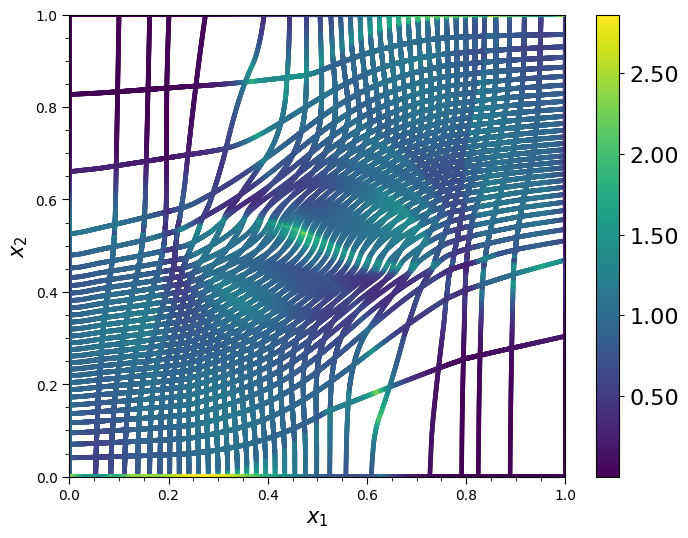

In [29]:
cl.distortion_plot(X, h)

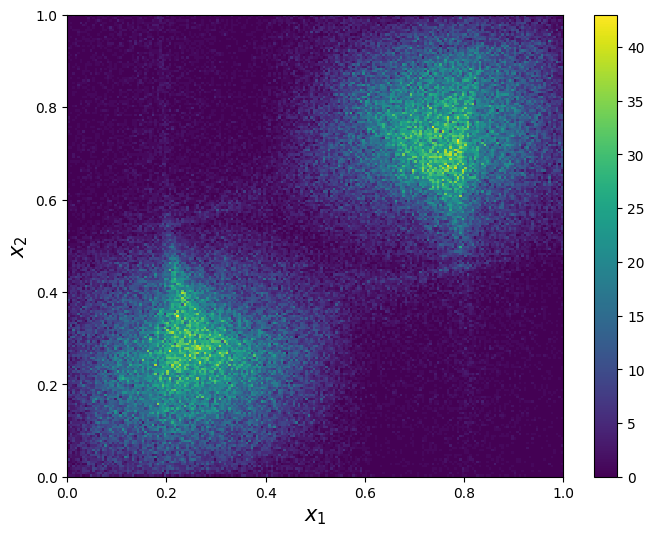

In [30]:
cl.plot_hist(flow=flow, num_samples=250000, bins=200, device='cpu')

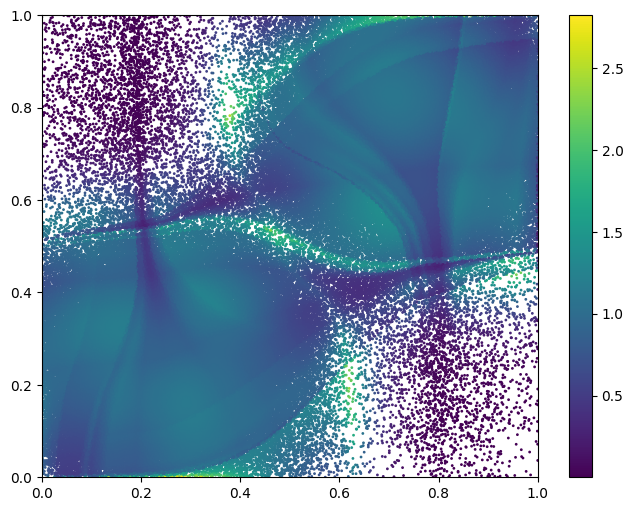

In [31]:
Y = torch.rand(250000, 2)
X, jacs = flow.inverse(Y)
X, jacs = X.detach(), jacs.detach()

cl.plot_weights(camel, X, jacs)